In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Jacobi function
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    ja_errors = []
    x = x0.copy()
    s
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        
        # Compute error and store it
        error = np.linalg.norm(x_new - x, ord=np.inf)
        ja_errors.append(error)
        
        # Check convergence
        if error < tol:
            return x_new, ja_errors
        
        x = x_new
    
    return x, ja_errors


In [25]:
# Gauss-Seidel function
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    ga_errors = []
    x = x0.copy()
    
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i))
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n))
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        
        # Compute error and store it
        error = np.linalg.norm(x_new - x, ord=np.inf)
        ga_errors.append(error)
        
        # Check convergence
        if error < tol:
            return x_new, ga_errors
        
        x = x_new
    
    return x, ga_errors

In [26]:
# System
A = np.array([
    [3, -0.1, -0.2], 
    [0.1, 7, -0.3], 
    [0.3, -0.2, 10]
], dtype=float)

b = np.array([7.85, -19.3, 71.4], dtype=float)
x0 = np.zeros_like(b)
max_iterations = 100

# Tolerances
tol = [1e-3, 1e-6, 1e-9]

# Store number of iterations for each tolerance
itn_list_ja = []
itn_list_ga = []


In [27]:
for t in tol:
    solution, errors = jacobi(A, b, x0, t, max_iterations)
    itn_list_ja.append(len(errors))
    
for t in tol:
    solution, errors = gauss_seidel(A, b, x0, t, max_iterations)
    itn_list_ga.append(len(errors))

print("Jacobi iterations:", itn_list_ja)
print("Gauss-Seidel iterations:", itn_list_ga)

Jacobi iterations: [4, 7, 9]
Gauss-Seidel iterations: [4, 5, 7]


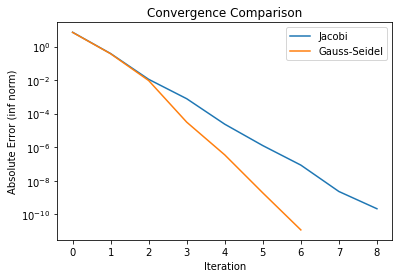

In [28]:
# Plot convergence for the last (smallest) tolerance
x_j, errors_j = jacobi(A, b, x0, 1e-9, max_iterations)
x_gs, errors_gs = gauss_seidel(A, b, x0, 1e-9, max_iterations)

plt.figure()
plt.plot(errors_j, label="Jacobi")
plt.plot(errors_gs, label="Gauss-Seidel")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Absolute Error (inf norm)")
plt.title("Convergence Comparison")
plt.legend()
plt.show()